In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/clustered_violations.csv")
cluster_summary = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary.csv")

df = df[df["cluster_id"] != -1].copy()

print(f"Loaded {len(df):,} clustered records (noise excluded)")
print(f"Clusters: {df['cluster_id'].nunique()}")
df.head(3)

Loaded 86,073 clustered records (noise excluded)
Clusters: 30


,id,latitude,longitude,police_station,junction_name,junction_code,at_junction,created_dt,date,hour,...,violation_count,severity_score,is_parking_related,vehicle_type,vehicle_weight,validation_status,point_repeat_count,is_repeated_point,cluster_id,cluster_probability
0,FKID000000,12.925557,77.618665,Madiwala,No Junction,NaN,0,2023-11-20 00:28:46+00:00,2023-11-20,0,...,2,3,1,CAR,1.0,approved,1,0,7,0.633944
1,FKID000002,12.925449,77.618504,Madiwala,No Junction,NaN,0,2023-11-20 00:27:46+00:00,2023-11-20,0,...,2,4,1,CAR,1.0,approved,1,0,7,0.633944
2,FKID000003,12.956521,77.518618,Byatarayanapura,No Junction,NaN,0,2023-11-16 06:47:46+00:00,2023-11-16,6,...,1,2,1,SCOOTER,0.4,approved,1,0,12,1.000000


## 1. Hour-of-day histogram per cluster

For each cluster, count violations per hour (0–23). This is the raw input for
peak-hour extraction and the entropy score below.


In [15]:
hour_hist = (
    df.groupby(["cluster_id", "hour"])
      .size()
      .reset_index(name="count")
)

hour_pivot = hour_hist.pivot(index="cluster_id", columns="hour", values="count").fillna(0)
hour_pivot = hour_pivot.reindex(columns=range(24), fill_value=0)

print(f"Hour pivot shape: {hour_pivot.shape}")
hour_pivot.head()

Hour pivot shape: (30, 24)


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,147.0,71.0,175.0,119.0,137.0,143.0,175.0,167.0,112.0,66.0,...,0.0,0.0,0.0,0.0,2.0,196.0,154.0,163.0,200.0,388.0
1,118.0,64.0,76.0,137.0,166.0,400.0,329.0,174.0,122.0,9.0,...,0.0,0.0,0.0,0.0,0.0,24.0,94.0,126.0,133.0,121.0
2,112.0,208.0,180.0,116.0,145.0,114.0,45.0,10.0,11.0,9.0,...,0.0,0.0,0.0,0.0,0.0,25.0,56.0,153.0,158.0,345.0
3,30.0,30.0,122.0,95.0,114.0,215.0,141.0,93.0,54.0,12.0,...,2.0,2.0,1.0,21.0,142.0,311.0,237.0,52.0,60.0,51.0
4,109.0,205.0,174.0,138.0,235.0,181.0,167.0,80.0,53.0,36.0,...,0.0,0.0,0.0,0.0,6.0,146.0,156.0,177.0,114.0,72.0


## 2. Day-of-week histogram per cluster

Same idea, but for day_of_week (0=Monday … 6=Sunday).


In [16]:
day_hist = (
    df.groupby(["cluster_id", "day_of_week"])
      .size()
      .reset_index(name="count")
)

day_pivot = day_hist.pivot(index="cluster_id", columns="day_of_week", values="count").fillna(0)
day_pivot = day_pivot.reindex(columns=range(7), fill_value=0)
day_pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

print(f"Day pivot shape: {day_pivot.shape}")
day_pivot.head()

Day pivot shape: (30, 7)


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
cluster_id,,,,,,,
0,384,338,370,316,435,249,333
1,399,300,338,171,276,274,350
2,349,379,326,138,123,228,145
3,183,255,329,292,216,222,292
4,248,225,308,334,366,243,341


## 3. Peak hour / peak day extraction

For each cluster: which single hour and which single day carry the most violations,
plus the % of the cluster's total volume concentrated in the top-3 hours and
top-2 days. This gives a quick human-readable "when" signature per zone.


In [17]:
def get_peak_window(row_series, top_n):
    sorted_vals = row_series.sort_values(ascending=False)
    top_items = sorted_vals.head(top_n)
    total = row_series.sum()
    pct = top_items.sum() / total if total > 0 else 0
    return list(top_items.index), round(pct, 3)

peak_hours_list = []
peak_hours_pct  = []
peak_days_list  = []
peak_days_pct   = []

for cid in hour_pivot.index:
    hrs, hpct = get_peak_window(hour_pivot.loc[cid], top_n=3)
    peak_hours_list.append(hrs)
    peak_hours_pct.append(hpct)

for cid in day_pivot.index:
    dys, dpct = get_peak_window(day_pivot.loc[cid], top_n=2)
    peak_days_list.append(dys)
    peak_days_pct.append(dpct)

temporal_profile = pd.DataFrame({
    "cluster_id": hour_pivot.index,
    "peak_hours": peak_hours_list,
    "peak_hours_pct": peak_hours_pct,
    "peak_days": peak_days_list,
    "peak_days_pct": peak_days_pct,
})

temporal_profile

,cluster_id,peak_hours,peak_hours_pct,peak_days,peak_days_pct
0,0,"[23, 22, 19]",0.323,"[Fri, Mon]",0.338
1,1,"[5, 6, 7]",0.428,"[Mon, Sun]",0.355
2,2,"[23, 1, 2]",0.434,"[Tue, Mon]",0.431
3,3,"[19, 20, 5]",0.426,"[Wed, Sun]",0.347
4,4,"[4, 1, 5]",0.301,"[Fri, Sun]",0.342
5,5,"[2, 0, 1]",0.397,"[Thu, Mon]",0.420
6,6,"[23, 22, 0]",0.441,"[Thu, Wed]",0.454
7,7,"[21, 5, 6]",0.303,"[Sun, Wed]",0.333
8,8,"[5, 22, 23]",0.385,"[Tue, Wed]",0.407
9,9,"[2, 1, 23]",0.345,"[Sun, Fri]",0.378


## 4. Entropy score — time concentration vs spread

Low entropy = violations concentrated in a narrow time window (highly predictable,
easy to schedule patrol around). High entropy = violations spread evenly across
hours/days (unpredictable, harder to plan for).

Entropy is computed on the normalized hour distribution per cluster, using
`scipy.stats.entropy` (natural log base), then min-max scaled to 0–1 for
readability (0 = perfectly concentrated, 1 = maximally spread across 24 hours).


In [18]:
def normalized_entropy(counts):
    counts = np.array(counts, dtype=float)
    if counts.sum() == 0:
        return np.nan
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    raw_entropy = entropy(probs)          # natural log
    max_entropy = np.log(len(counts))     # max possible entropy for this many bins
    return raw_entropy / max_entropy if max_entropy > 0 else 0

hour_entropy = hour_pivot.apply(lambda row: normalized_entropy(row.values), axis=1)
day_entropy  = day_pivot.apply(lambda row: normalized_entropy(row.values), axis=1)

temporal_profile["hour_entropy"] = temporal_profile["cluster_id"].map(hour_entropy)
temporal_profile["day_entropy"]  = temporal_profile["cluster_id"].map(day_entropy)

temporal_profile[["cluster_id","hour_entropy","day_entropy"]].sort_values("hour_entropy")

,cluster_id,hour_entropy,day_entropy
14,14,0.688426,0.892928
24,24,0.695740,0.980205
23,23,0.699953,0.921415
6,6,0.718042,0.896506
17,17,0.733504,0.996518
28,28,0.737519,0.991394
15,15,0.748772,0.979496
2,2,0.750428,0.953629
20,20,0.752807,0.991827
5,5,0.760273,0.948762


## 5. Time Risk score

Combines entropy and peak concentration into a single 0–1 score:
low entropy (predictable) + high peak concentration → high Time Risk
(easy to target with scheduled enforcement, high payoff per patrol hour).

```
Time Risk = (1 - hour_entropy) * 0.6 + peak_hours_pct * 0.4
```


In [19]:
temporal_profile["time_risk"] = (
    (1 - temporal_profile["hour_entropy"]) * 0.6
    + temporal_profile["peak_hours_pct"] * 0.4
)

temporal_profile[["cluster_id","hour_entropy","peak_hours_pct","time_risk"]]\
    .sort_values("time_risk", ascending=False)

,cluster_id,hour_entropy,peak_hours_pct,time_risk
14,14,0.688426,0.551,0.407344
24,24,0.695740,0.520,0.390556
23,23,0.699953,0.487,0.374828
17,17,0.733504,0.488,0.355097
28,28,0.737519,0.483,0.350689
6,6,0.718042,0.441,0.345575
20,20,0.752807,0.448,0.327516
2,2,0.750428,0.434,0.323343
15,15,0.748772,0.430,0.322737
5,5,0.760273,0.397,0.302636


## 6. Night vs day split per cluster

Carries forward the global night-peak finding (53.2% of all violations occur
0–5am) to check whether it holds uniformly across clusters or whether some
clusters are day-dominant.


In [20]:
night_hours = list(range(0, 6))

df["is_night"] = df["hour"].isin(night_hours).astype(int)

night_split = (
    df.groupby("cluster_id")["is_night"]
      .mean()
      .reset_index(name="night_violation_pct")
)

temporal_profile = temporal_profile.merge(night_split, on="cluster_id")
temporal_profile[["cluster_id","night_violation_pct","time_risk"]]\
    .sort_values("night_violation_pct", ascending=False)

,cluster_id,night_violation_pct,time_risk
24,24,0.765751,0.390556
23,23,0.714002,0.374828
20,20,0.705015,0.327516
11,11,0.700092,0.298962
27,27,0.675557,0.290899
21,21,0.653376,0.298309
5,5,0.634306,0.302636
29,29,0.626387,0.271695
9,9,0.583510,0.254775
6,6,0.576196,0.345575


## 7. Visual profiles — hour heatmap across all clusters

One heatmap, clusters on the y-axis, hours on the x-axis, so all 30 temporal
signatures can be compared side by side at a glance.


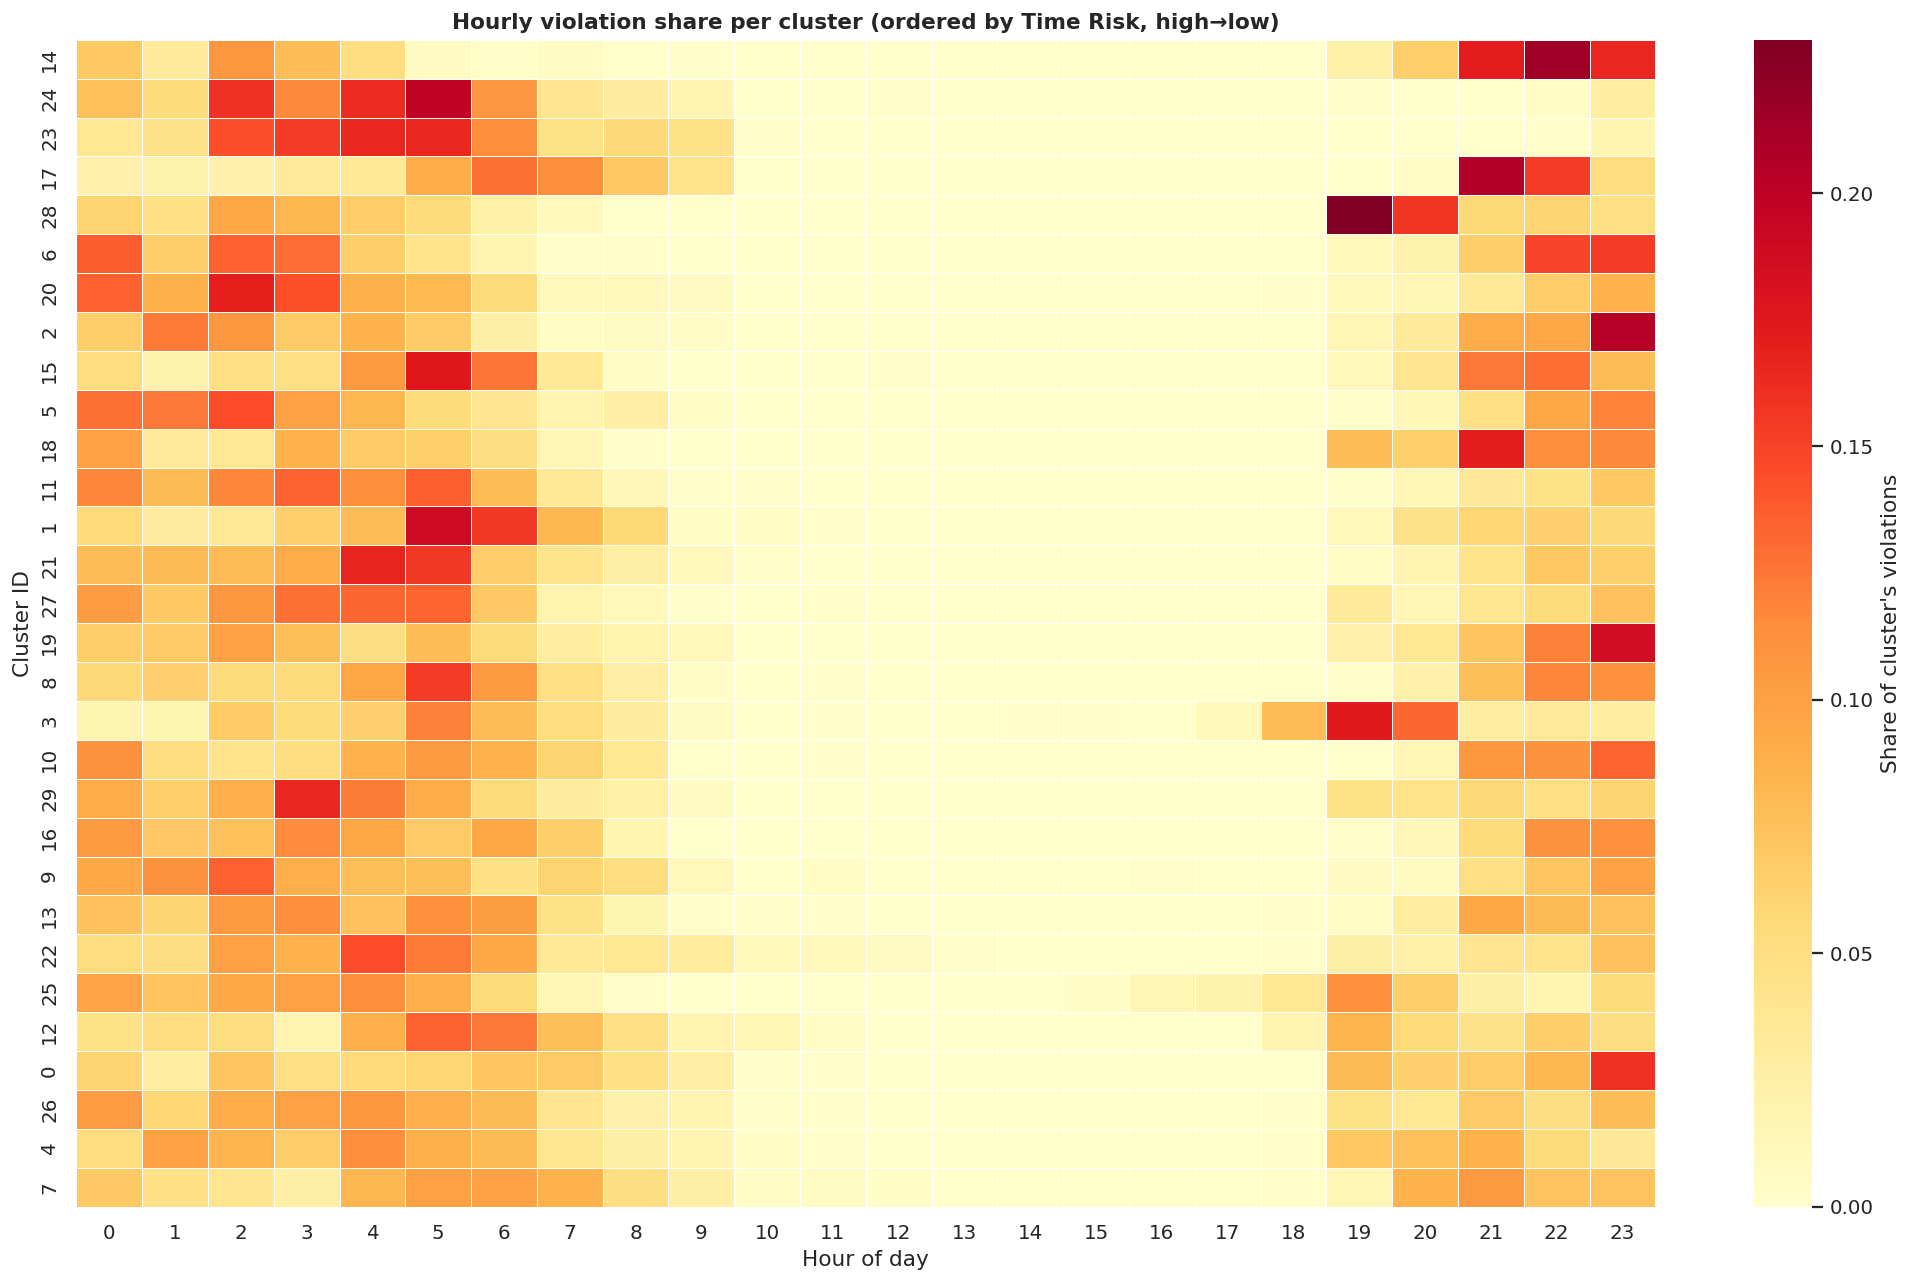

In [21]:
fig, ax = plt.subplots(figsize=(16, 10))

# order clusters by time_risk for readability
ordered_clusters = temporal_profile.sort_values("time_risk", ascending=False)["cluster_id"]
hour_pivot_ordered = hour_pivot.loc[ordered_clusters]

# normalize each row so patterns are visible regardless of cluster size
hour_pivot_norm = hour_pivot_ordered.div(hour_pivot_ordered.sum(axis=1), axis=0)

sns.heatmap(hour_pivot_norm, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Share of cluster's violations"})
ax.set_title("Hourly violation share per cluster (ordered by Time Risk, high→low)",
             fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig("s3_hourly_heatmap_all_clusters.png")
plt.show()

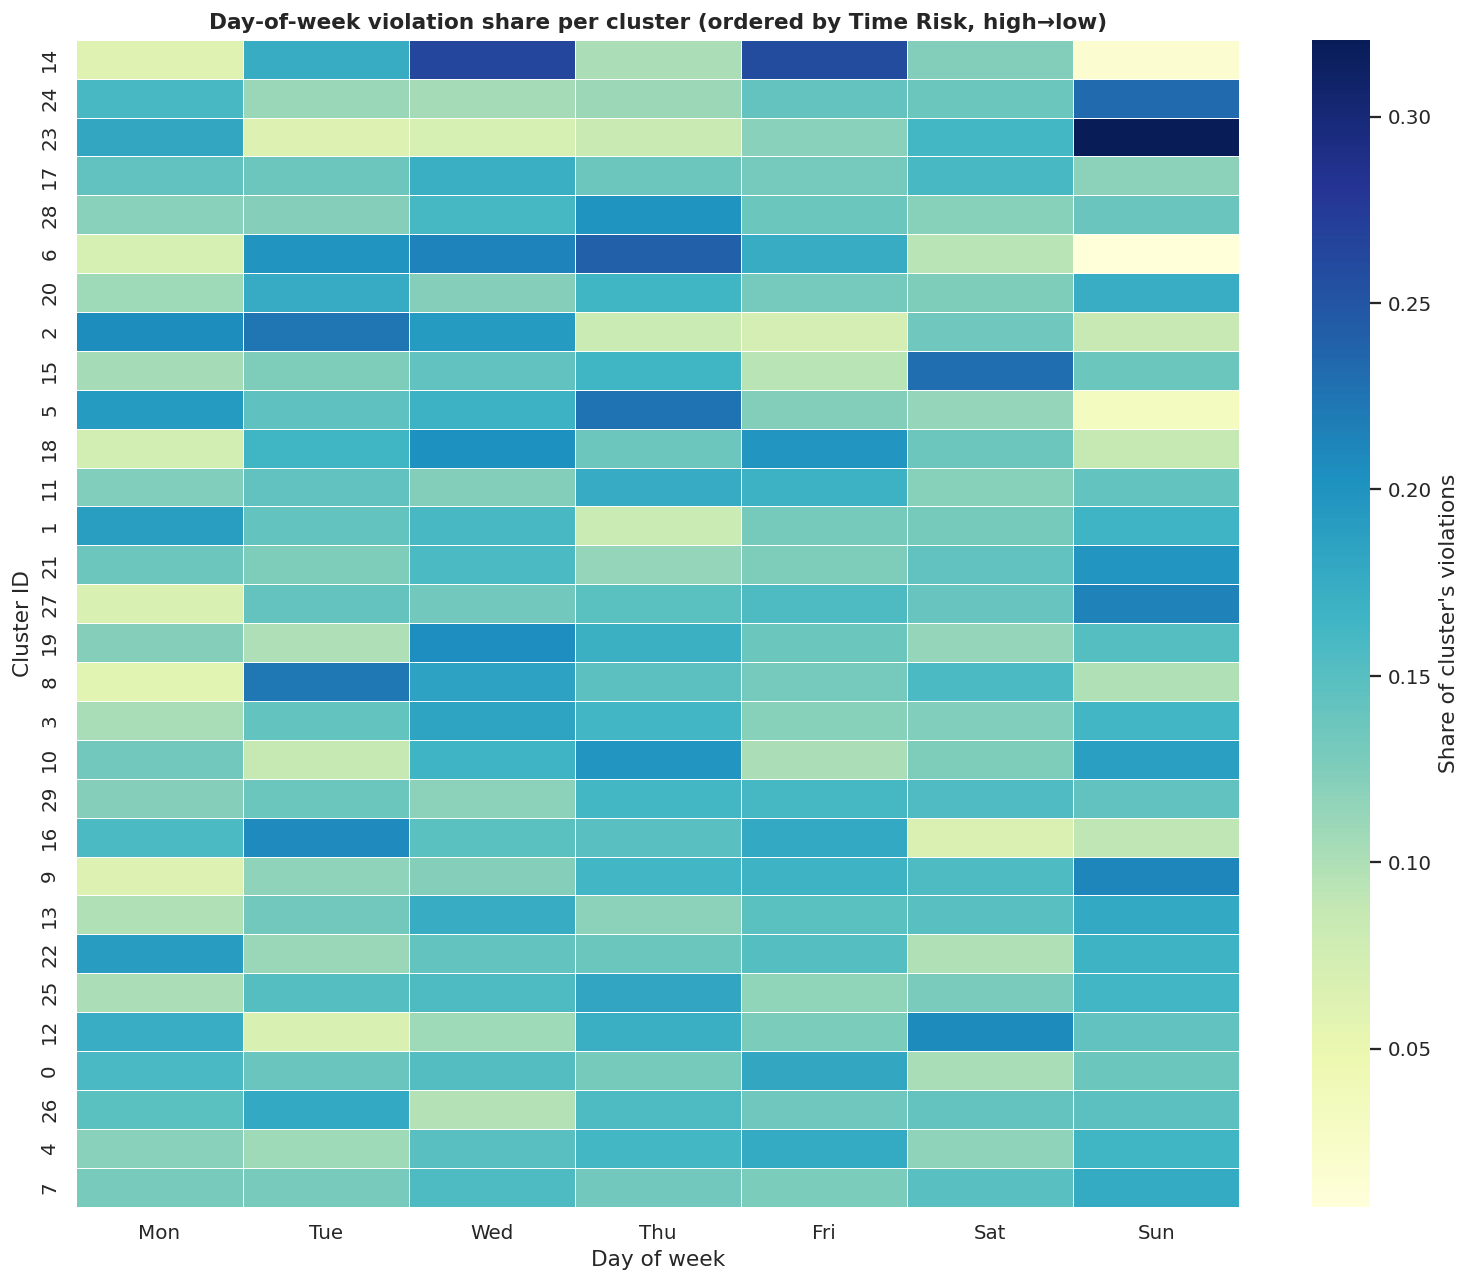

In [22]:
fig, ax = plt.subplots(figsize=(12, 10))

day_pivot_ordered = day_pivot.loc[ordered_clusters]
day_pivot_norm = day_pivot_ordered.div(day_pivot_ordered.sum(axis=1), axis=0)

sns.heatmap(day_pivot_norm, cmap="YlGnBu", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Share of cluster's violations"})
ax.set_title("Day-of-week violation share per cluster (ordered by Time Risk, high→low)",
             fontweight="bold")
ax.set_xlabel("Day of week")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig("s3_daily_heatmap_all_clusters.png")
plt.show()

## 8. Individual cluster profile plots (top 6 by size)

Detailed hour + day bar charts for the largest clusters, for closer inspection.


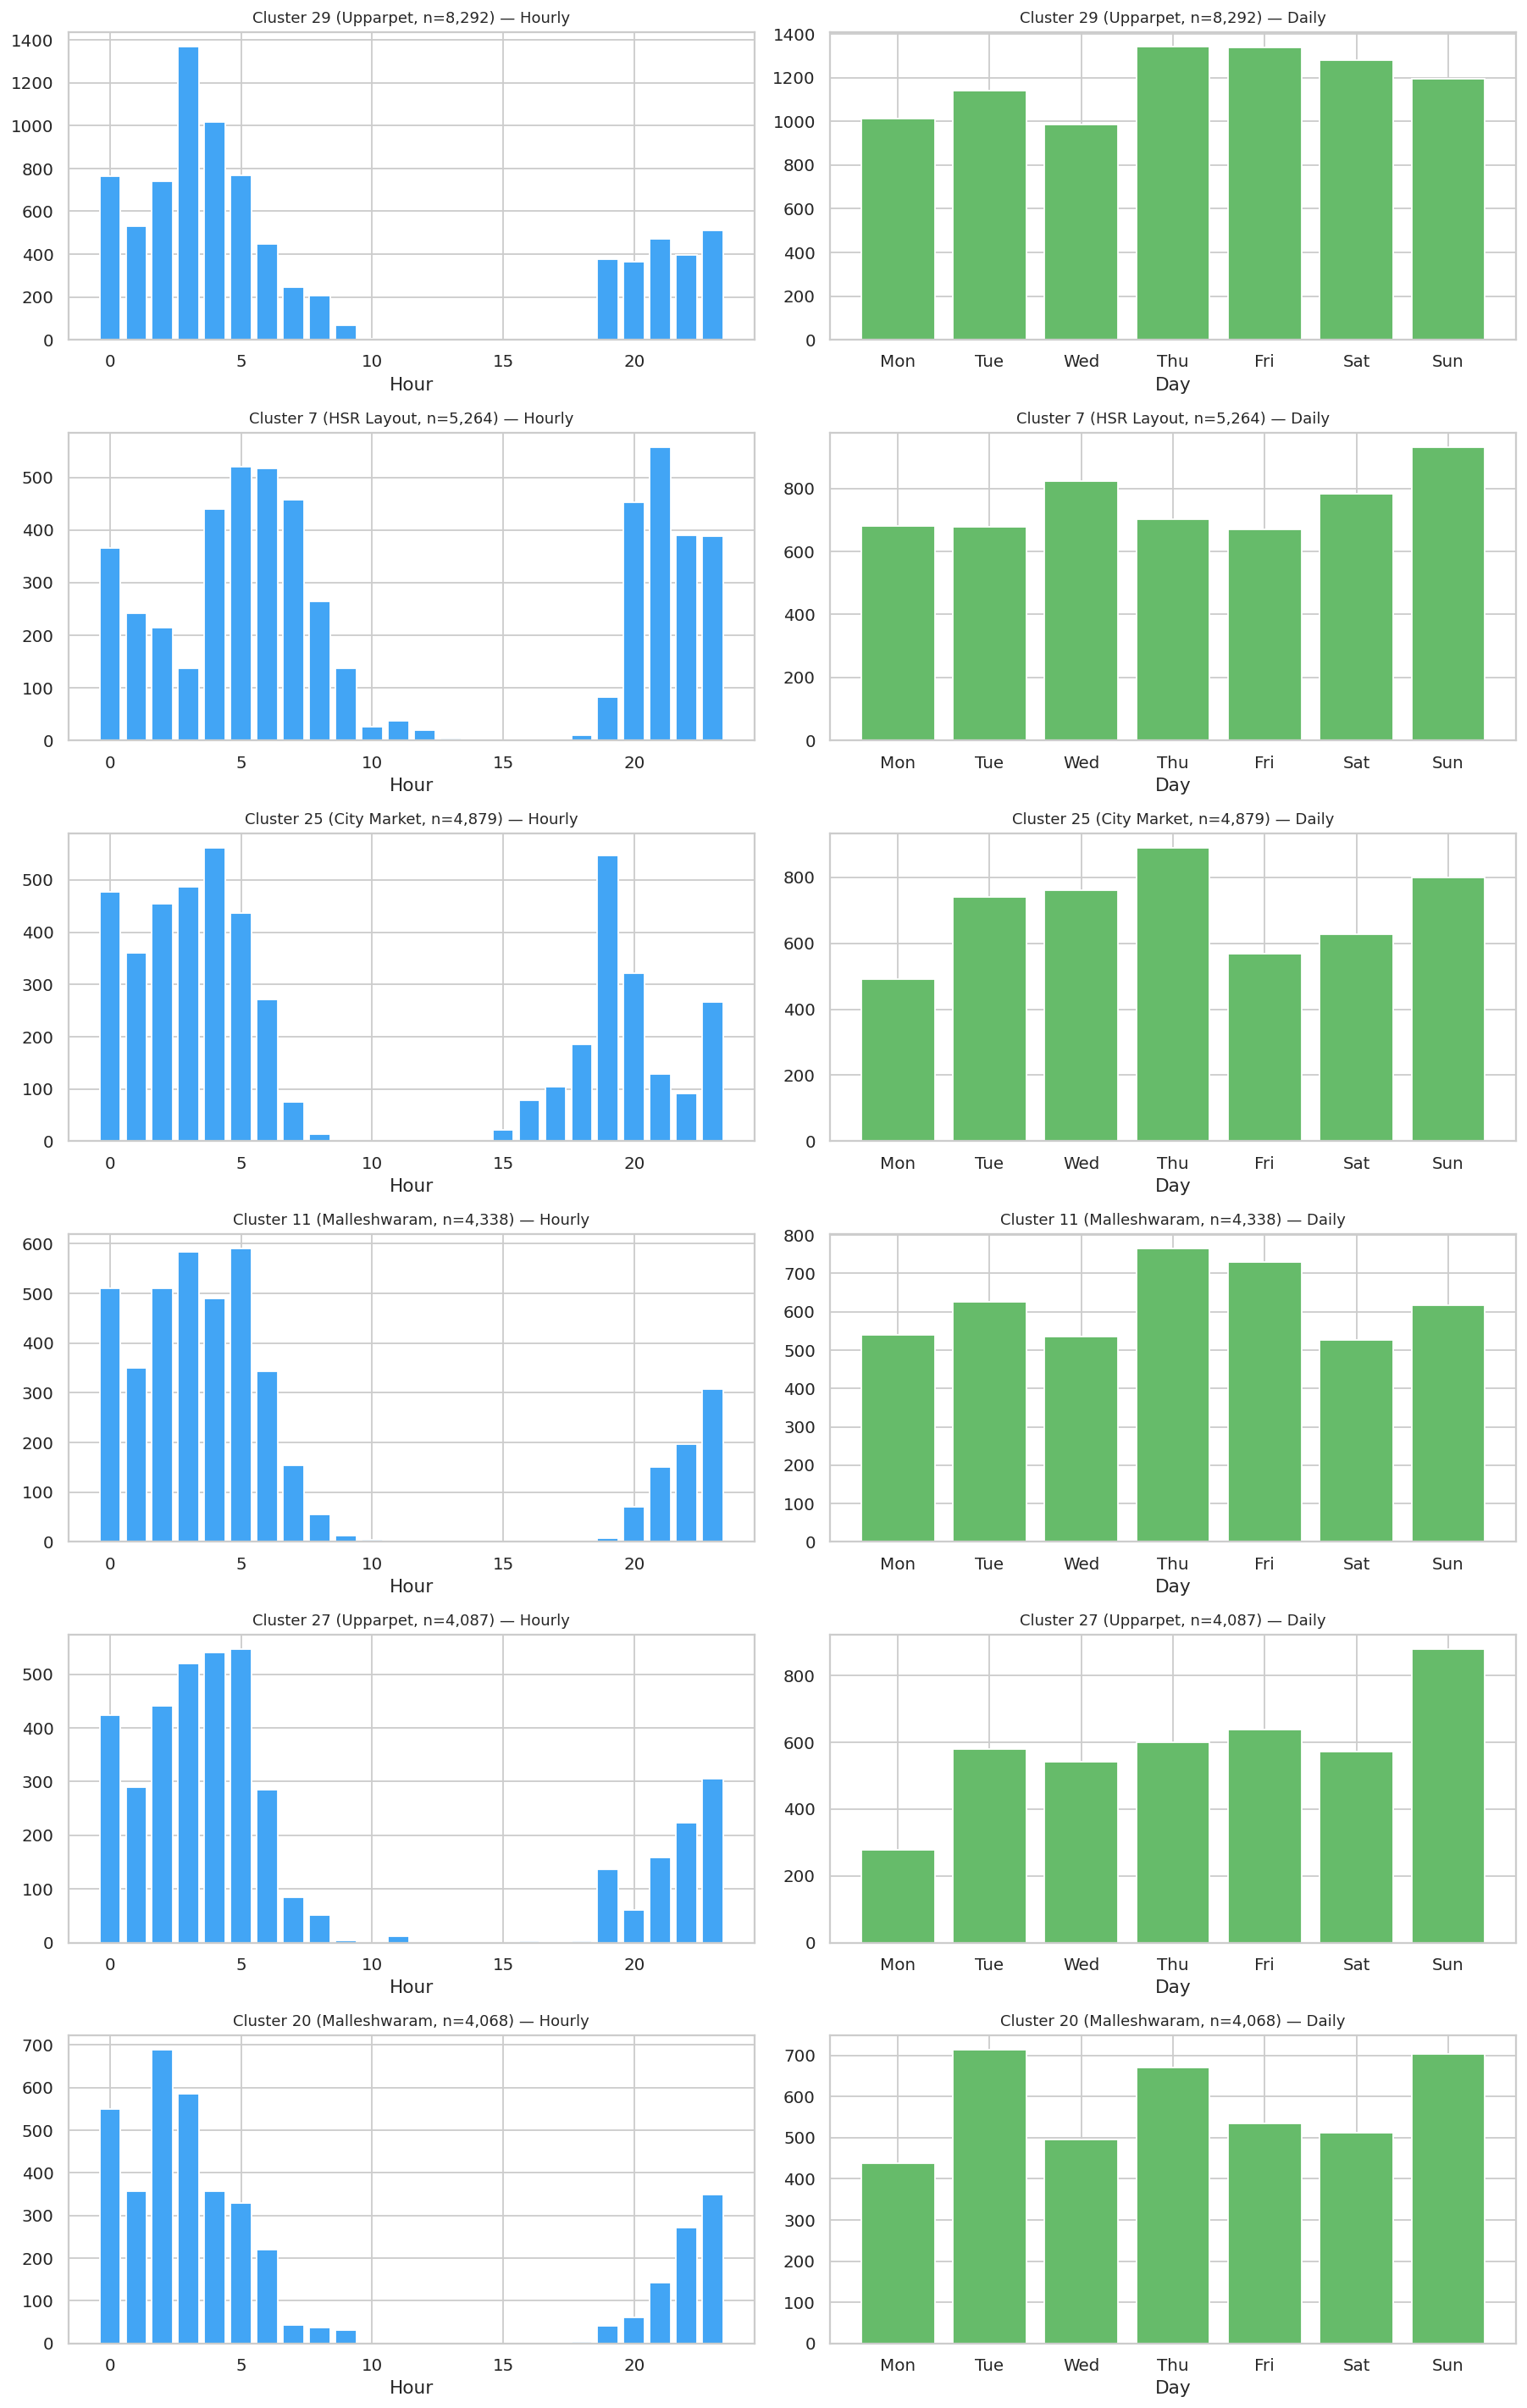

In [23]:
top6_clusters = cluster_summary.sort_values("size", ascending=False)["cluster_id"].head(6).tolist()

fig, axes = plt.subplots(6, 2, figsize=(14, 22))

for i, cid in enumerate(top6_clusters):
    station = cluster_summary.loc[cluster_summary["cluster_id"]==cid, "top_station"].values[0]
    size    = cluster_summary.loc[cluster_summary["cluster_id"]==cid, "size"].values[0]

    axes[i,0].bar(hour_pivot.columns, hour_pivot.loc[cid], color="#42A5F5")
    axes[i,0].set_title(f"Cluster {cid} ({station}, n={size:,}) — Hourly", fontsize=10)
    axes[i,0].set_xlabel("Hour")

    axes[i,1].bar(day_pivot.columns, day_pivot.loc[cid], color="#66BB6A")
    axes[i,1].set_title(f"Cluster {cid} ({station}, n={size:,}) — Daily", fontsize=10)
    axes[i,1].set_xlabel("Day")

plt.tight_layout()
plt.savefig("s3_top6_cluster_profiles.png")
plt.show()

## 9. Merge temporal profile into cluster_summary and save


In [24]:
cluster_summary = cluster_summary.merge(temporal_profile, on="cluster_id", how="left")

# Store raw hour/day distributions separately (wide format) for any later use
hour_pivot_out = hour_pivot.reset_index()
hour_pivot_out.columns = ["cluster_id"] + [f"hour_{h}" for h in range(24)]

day_pivot_out = day_pivot.reset_index()
day_pivot_out.columns = ["cluster_id"] + [f"day_{d}" for d in day_pivot.columns]

cluster_summary.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_updated.csv", index=False)
temporal_profile.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_temporal_profiles.csv", index=False)
hour_pivot_out.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_hourly_distribution.csv", index=False)
day_pivot_out.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_daily_distribution.csv", index=False)

print("Saved:")
print("  cluster_summary.csv (updated)      —", cluster_summary.shape)
print("  cluster_temporal_profiles.csv      —", temporal_profile.shape)
print("  cluster_hourly_distribution.csv    —", hour_pivot_out.shape)
print("  cluster_daily_distribution.csv     —", day_pivot_out.shape)

cluster_summary.head()

Saved:
  cluster_summary.csv (updated)      — (30, 21)
  cluster_temporal_profiles.csv      — (30, 9)
  cluster_hourly_distribution.csv    — (30, 25)
  cluster_daily_distribution.csv     — (30, 8)


,cluster_id,size,centroid_lat,centroid_lon,avg_severity,avg_vehicle_weight,junction_ratio,repeated_point_ratio,avg_cluster_prob,multi_violation_pct,...,top_station_pct,likely_camera_artifact,peak_hours,peak_hours_pct,peak_days,peak_days_pct,hour_entropy,day_entropy,time_risk,night_violation_pct
0,29,8292,12.977098,77.576941,2.028341,0.700832,0.998070,0.012301,0.757619,0.040762,...,0.999759,False,"[3, 4, 5]",0.381,"[Thu, Fri]",0.323,0.801175,0.996537,0.271695,0.626387
1,7,5264,12.915963,77.625859,2.182181,0.797169,0.293693,0.019757,0.931220,0.110562,...,0.341565,False,"[21, 5, 6]",0.303,"[Sun, Wed]",0.333,0.841276,0.996373,0.216435,0.364742
2,25,4879,12.964669,77.578713,2.076860,0.650318,0.992416,0.002869,0.668112,0.059643,...,0.659561,False,"[4, 19, 3]",0.327,"[Thu, Sun]",0.346,0.826469,0.990953,0.234919,0.568969
3,11,4338,13.000357,77.570468,2.013601,0.784693,0.005071,0.012218,0.704725,0.016367,...,0.790226,False,"[5, 3, 2]",0.388,"[Thu, Fri]",0.344,0.760397,0.994806,0.298962,0.700092
4,27,4087,12.971175,77.577458,2.132860,0.637240,0.904575,0.025691,0.830219,0.097627,...,0.496452,False,"[5, 4, 3]",0.393,"[Sun, Fri]",0.371,0.777168,0.978976,0.290899,0.675557
